In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class CircleFit:
  def __init__(self, alpha, max_iter) -> None:
    self.alpha = alpha
    self.max_iter = max_iter
    self.a = 0
    self.b = 0
    self.r = 0

  def J(self, X, m):
    dist_center = np.linalg.norm(X - (self.a,self.b), axis=1)
    dist_circle = dist_center - self.r
    return np.sum(dist_circle**2) / m

  def fit(self, X, termination_diff, verbose=0):
    m = len(X)

    # initialize variables
    self.a = np.mean(X[:,0])
    self.b = np.mean(X[:,1])
    self.r = 1

    history = []
    old_loss = np.inf
    for iter in range(self.max_iter):
      curr_loss = self.J(X, m)
      history.append(curr_loss)

      if verbose == 2:
        print(f"Iter {iter} -> Loss: {curr_loss}")

      if verbose == 1 and iter % 10 == 0:
        print(f"Iter {iter} -> Loss: {curr_loss}")

      if np.abs(old_loss - curr_loss) < termination_diff:
        break

      old_loss = curr_loss

      diff = X - np.array([self.a, self.b])
      dist_center = np.linalg.norm(diff, axis=1) + 1e-8

      left = 1.0 - (self.r / dist_center)

      J_a = (-2.0 / m) * np.sum(left * diff[:, 0])
      J_b = (-2.0 / m) * np.sum(left * diff[:, 1])
      J_r = (-2.0 / m) * np.sum(dist_center - self.r)

      self.a -= self.alpha * J_a
      self.b -= self.alpha * J_b
      self.r -= self.alpha * J_r

    print(f"Final loss: {self.J(X, m)}")
    return history

  def get_params(self):
    return self.a, self.b, self.r


In [3]:
def generate_ring_dataset(radius, center, n_samples, noise):
    angles = np.random.uniform(0, 2 * np.pi, n_samples)

    r = radius + np.random.normal(0, noise, n_samples)

    x = center[0] + r * np.cos(angles)
    y = center[1] + r * np.sin(angles)

    return np.column_stack((x, y))

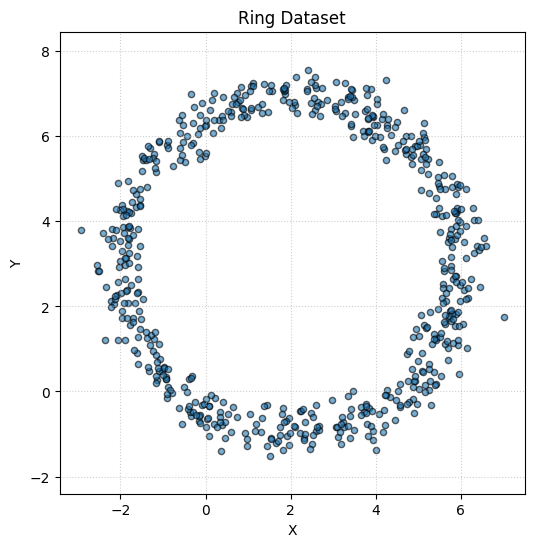

In [4]:
data = generate_ring_dataset(
    radius=4.0,
    center=(2.0, 3.0),
    n_samples=600,
    noise=0.3
)

# Çizdir
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, edgecolors='k', s=20)
plt.title("Ring Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [10]:
model = CircleFit(alpha=0.005, max_iter=1000)
history = model.fit(data, termination_diff=0.0001, verbose=1)

Iter 0 -> Loss: 9.014481250787876
Iter 10 -> Loss: 7.392087566706758
Iter 20 -> Loss: 6.064986011238984
Iter 30 -> Loss: 4.979397656302377
Iter 40 -> Loss: 4.0913403867593585
Iter 50 -> Loss: 3.3648438909581895
Iter 60 -> Loss: 2.7704899971083123
Iter 70 -> Loss: 2.2842190109601854
Iter 80 -> Loss: 1.886353552942813
Iter 90 -> Loss: 1.5608002474280591
Iter 100 -> Loss: 1.29439685058445
Iter 110 -> Loss: 1.0763783146898938
Iter 120 -> Loss: 0.8979401185275859
Iter 130 -> Loss: 0.7518811433750104
Iter 140 -> Loss: 0.6323116034301798
Iter 150 -> Loss: 0.5344141799714079
Iter 160 -> Loss: 0.4542486676423159
Iter 170 -> Loss: 0.3885922068326097
Iter 180 -> Loss: 0.3348086199664144
Iter 190 -> Loss: 0.29074155027945914
Iter 200 -> Loss: 0.25462706731996804
Iter 210 -> Loss: 0.22502219315138783
Iter 220 -> Loss: 0.200746449122582
Iter 230 -> Loss: 0.18083405131308666
Iter 240 -> Loss: 0.16449481478958292
Iter 250 -> Loss: 0.15108218015120092
Iter 260 -> Loss: 0.14006706482815734
Iter 270 -> L

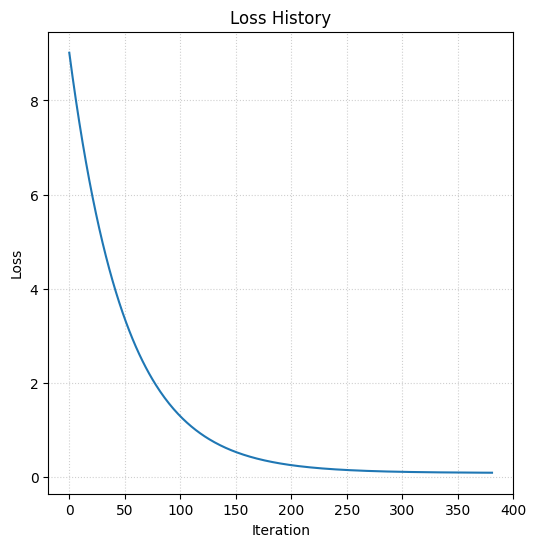

In [11]:
plt.figure(figsize=(6, 6))
plt.plot(history)
plt.title("Loss History")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, linestyle=':', alpha=0.6)

In [12]:
a, b, r = model.get_params()
print(f"a: {a}, b: {b}, r: {r}")

a: 2.053553183068634, b: 2.9909132013135777, r: 3.9232316689430955


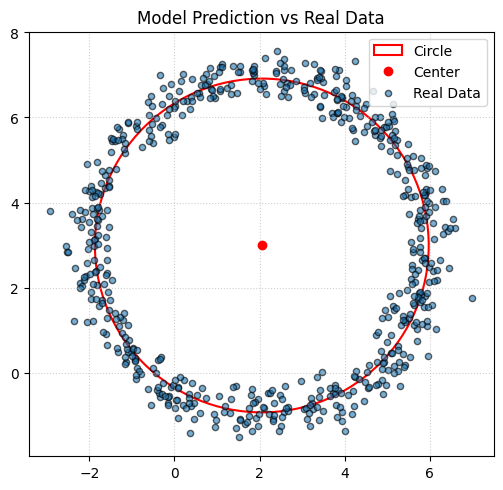

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))

circle = plt.Circle((a, b), r, color='red', fill=False, linewidth=1.5, label='Circle')
ax.add_patch(circle)

ax.plot(a, b, 'ro', label='Center')
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, edgecolors='k', s=20, label="Real Data")

ax.set_aspect('equal')

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.title("Model Prediction vs Real Data")
plt.show()